<a href="https://colab.research.google.com/github/LinaSeguro/Proyecto-Integrado-III-Analisis-Produccion-Agricola/blob/main/An%C3%A1lisis_de_Rendimiento_Agr%C3%ADcola_en_Colombia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proyecto Integrado III Analítica de Datos**

###**Integrantes del proyecto**

- JUSTIN BECKHAN CARDONA
- JORGE ARMANDO RODRIGUEZ  
- LINA JOHANA SEGURO GAVIRIA


# **Exploración de Datos:**
**Objetivo:** Analizar la calidad de la base de datos de Evaluaciones Agropecuarias Municipales (EVA) 2019-2024 para identificar
* Duplicados
* Valores nulos
* Tipos de datos
* Distribuciones
* Correlaciones
* Resumen estadístico

## **Instalación de librerias y Carga del Dataset**

In [13]:
# Instalación de la librería necesaria
!pip install ydata-profiling

import pandas as pd
from ydata_profiling import ProfileReport

# Carga del dataset
from google.colab import drive
drive.mount('/content/drive')

# Ruta
df = pd.read_csv('/content/drive/MyDrive/Proyecto_Integrado_III/Dataset_EVA_2019_2024.csv')

print("Dataset cargado exitosamente. Dimensiones:", df.shape)

^C
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado exitosamente. Dimensiones: (141073, 18)


## **1. Estructura y Tipos de Datos**
En esta sección verificamos la cantidad de registros y si las columnas tienen el formato correcto (numérico o texto).

In [2]:
# Muestra el número de filas, columnas, tipos de datos y si hay nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141073 entries, 0 to 141072
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   Código Dane departamento       141073 non-null  int64 
 1   Departamento                   141073 non-null  object
 2   Código Dane municipio          141073 non-null  int64 
 3   Municipio                      141073 non-null  object
 4   Grupo cultivo                  141073 non-null  object
 5   Subgrupo                       141073 non-null  object
 6   Cultivo                        141073 non-null  object
 7   Desagregación cultivo          141073 non-null  object
 8   Año                            141073 non-null  int64 
 9   Periodo                        141073 non-null  object
 10  Área sembrada                  141073 non-null  object
 11  Área cosechada                 141073 non-null  object
 12  Producción                     141073 non-nu

**Conclusión sobre variables numéricas**

Se identificó que variables como área sembrada, área cosechada, producción y rendimiento estaban almacenadas como texto (object), por lo que es necesario convertirlas a formato numérico para poder realizar correctamente el análisis estadístico.

## **2. Exploración de Datos - Visualización Inicial**
En esta sección se realiza la primera inspección visual del conjunto de datos. Esta visualización permite:
* Confirmar la carga correcta de las 18 columnas.
* Entender la relación entre las variables geográficas (Departamento/Municipio) y las métricas de producción.
* Identificar la estructura de los datos (cada fila representa un cultivo por municipio y año).

In [3]:
# Concatenar las primeras 10 y las últimas 10 filas
# El uso de pd.concat permite visualizar ambos extremos en una sola tabla
inspeccion_extremos = pd.concat([df.head(10), df.tail(10)])

# Mostrar el resultado
inspeccion_extremos

,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Grupo cultivo,Subgrupo,Cultivo,Desagregación cultivo,Año,Periodo,Área sembrada,Área cosechada,Producción,Rendimiento,Ciclo del cultivo,Estado físico del cultivo,Código del cultivo,Nombre científico del cultivo
0,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate demás variedades,2019,2019,"24,00","23,00","138,00","6,00",Permanente,En fresco,2040299,Persea americana
1,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate demás variedades,2020,2020,"8,52","3,52","21,12","6,00",Permanente,En fresco,2040299,Persea americana
2,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate demás variedades,2021,2021,"8,52","4,52","27,12","6,00",Permanente,En fresco,2040299,Persea americana
3,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate demás variedades,2022,2022,"17,17","8,52","51,12","6,00",Permanente,En fresco,2040299,Persea americana
4,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate demás variedades,2023,2023,"14,97","8,52","51,12","6,00",Permanente,En fresco,2040299,Persea americana
5,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate demás variedades,2024,2024,"12,97","6,97","83,64","12,00",Permanente,En fresco,2040299,Persea americana
6,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate Hass,2020,2020,"15,48","15,48","92,88","6,00",Permanente,En fresco,2040201,Persea americana
7,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate Hass,2021,2021,"15,00","15,00","90,00","6,00",Permanente,En fresco,2040201,Persea americana
8,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate Hass,2022,2022,"15,00","15,00","90,00","6,00",Permanente,En fresco,2040201,Persea americana
9,5,Antioquia,5001,Medellín,Frutales,Demás frutales,Aguacate,Aguacate Hass,2023,2023,"11,00","11,00","77,00","7,00",Permanente,En fresco,2040201,Persea americana


## **3. Calidad de los Datos (Valores Nulos y Duplicados)**
Identificamos la presencia de valores faltantes y registros repetidos para asegurar la integridad del análisis.

In [4]:
print("--- Valores Nulos por Columna ---")
print(df.isnull().sum())
print("\n--- Cantidad de Registros Duplicados ---")
print(df.duplicated().sum())

--- Valores Nulos por Columna ---
Código Dane departamento         0
Departamento                     0
Código Dane municipio            0
Municipio                        0
Grupo cultivo                    0
Subgrupo                         0
Cultivo                          0
Desagregación cultivo            0
Año                              0
Periodo                          0
Área sembrada                    0
Área cosechada                   0
Producción                       0
Rendimiento                      0
Ciclo del cultivo                0
Estado físico del cultivo        0
Código del cultivo               0
Nombre científico del cultivo    0
dtype: int64

--- Cantidad de Registros Duplicados ---
0


**Conclusión de calidad de datos**

El dataset no tiene datos faltantes ni registros repetidos, lo que significa que la información está completa y en buen estado para hacer el análisis.

## **4. Limpieza y Transformación de Datos**
Se detectó que las columnas de **Área, Producción y Rendimiento** fueron cargadas como tipo object (texto) debido al formato de moneda/miles (4.900,00).

**Procedimiento de limpieza:**
1. Eliminar los puntos que actúan como separadores de miles.
2. Reemplazar las comas por puntos para el formato decimal estándar de Python.
3. Convertir las columnas a tipo float (numérico).

In [5]:
# Definir las columnas que deben ser numéricas
cols_a_limpiar = ['Área sembrada', 'Área cosechada', 'Producción', 'Rendimiento']

for col in cols_a_limpiar:
    # Paso 1: Convertir a string para asegurar que los métodos funcionen
    df[col] = df[col].astype(str)

    # Paso 2: Quitar los puntos de los miles (ej: 4.900,00 -> 4900,00)
    df[col] = df[col].str.replace('.', '', regex=False)

    # Paso 3: Cambiar la coma decimal por punto (ej: 4900,00 -> 4900.00)
    df[col] = df[col].str.replace(',', '.', regex=False)

    # Paso 4: Convertir a número (los errores se vuelven nulos temporalmente)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verificar el cambio
print(" Limpieza completada exitosamente.")
df[cols_a_limpiar].info()

 Limpieza completada exitosamente.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141073 entries, 0 to 141072
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Área sembrada   141073 non-null  float64
 1   Área cosechada  141073 non-null  float64
 2   Producción      141073 non-null  float64
 3   Rendimiento     141073 non-null  float64
dtypes: float64(4)
memory usage: 4.3 MB


###**4.1 Visualización del Dataset Post-Limpieza**
Tras el proceso de normalización y conversión de tipos, se realiza una inspección final. En esta vista se puede observar que las cifras de producción y rendimiento ya no presentan separadores de miles y están correctamente alineadas para cálculos matemáticos.

In [6]:
# 1. Ver las primeras 5 filas (Incluyendo todas las variables numéricas clave)
print("--- Muestra de datos limpios ---")
display(df[['Departamento', 'Municipio', 'Cultivo', 'Área sembrada', 'Área cosechada', 'Producción', 'Rendimiento']].head())

# 2. Confirmar que los tipos de datos ahora son float64 (confirmación técnica)
print("\n--- Verificación de tipos de datos finales ---")
df[['Área sembrada', 'Área cosechada', 'Producción', 'Rendimiento']].info()

--- Muestra de datos limpios ---


,Departamento,Municipio,Cultivo,Área sembrada,Área cosechada,Producción,Rendimiento
0,Antioquia,Medellín,Aguacate,24.00,23.00,138.00,6.0
1,Antioquia,Medellín,Aguacate,8.52,3.52,21.12,6.0
2,Antioquia,Medellín,Aguacate,8.52,4.52,27.12,6.0
3,Antioquia,Medellín,Aguacate,17.17,8.52,51.12,6.0
4,Antioquia,Medellín,Aguacate,14.97,8.52,51.12,6.0



--- Verificación de tipos de datos finales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141073 entries, 0 to 141072
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Área sembrada   141073 non-null  float64
 1   Área cosechada  141073 non-null  float64
 2   Producción      141073 non-null  float64
 3   Rendimiento     141073 non-null  float64
dtypes: float64(4)
memory usage: 4.3 MB


## **5. Resumen Estadístico**


**5.1 Análisis de las métricas principales** (media, desviación estándar, valores máximos y mínimos) de la producción y el rendimiento.

In [7]:
# Generar el resumen estadístico de las columnas numéricas recién limpiadas
resumen = df[['Área sembrada', 'Área cosechada', 'Producción', 'Rendimiento']].describe()

# Formatear para que no use notación científica (opcional, para que sea más fácil de leer)
resumen.apply(lambda s: s.apply('{0:.2f}'.format))

,Área sembrada,Área cosechada,Producción,Rendimiento
count,141073.00,141073.00,141073.00,141073.00
mean,230.32,210.58,3192.23,10.60
std,1167.62,1104.77,49055.99,15.54
min,0.00,0.00,0.00,0.00
25%,5.78,5.00,21.00,1.80
50%,20.00,18.00,104.00,6.00
75%,93.30,82.00,559.77,13.00
max,60000.00,61000.00,4776340.50,253.00


 Interpretación de los resultados:

* El rendimiento promedio en Colombia es de 10.60 t/ha, pero la mayoría de los datos están por debajo de ese valor (6.00 t/ha o menos). Esto indica que unos pocos cultivos con rendimientos muy altos aumentan el promedio.

* También se observa una gran variación en los datos, con algunos valores muy altos, lo que muestra que no todos los cultivos tienen la misma productividad.

* Se identificaron valores de 0.00 en variables métricas como área, producción y rendimiento. Estos valores requieren revisión dentro del proceso de limpieza para evaluar su impacto en el análisis y garantizar la calidad de los datos utilizados.

**5.2 Análisis Descriptivo de Variables Categóricas relevantes** (Departamento, Cultivo, Grupo cultivo, Estado físico del cultivo)

In [12]:
# Seleccionamos solo las variables categóricas que aportan valor al negocio
columnas_interes = ['Departamento', 'Cultivo', 'Grupo cultivo', 'Año', 'Estado físico del cultivo']

# Generamos el describe
resumen_categorico = df[columnas_interes].describe(include='object')

print("--- Resumen de Variables Categóricas Clave ---")
display(resumen_categorico)

--- Resumen de Variables Categóricas Clave ---


,Departamento,Cultivo,Grupo cultivo,Estado físico del cultivo
count,141073,141073,141073,141073
unique,32,166,8,10
top,Boyacá,Maíz,Frutales,En fresco
freq,14969,18490,41555,96544



Del resumen anterior se extraen las siguientes conclusiones fundamentales para la investigación:

* **Representatividad Nacional:** El estudio cuenta con datos de los **32 departamentos** de Colombia. Esto garantiza que el "Promedio Nacional" que utilizaremos para comparar el **Café** sea un referente real y completo de todo el país.
* **Diversidad de Cultivos:** Se analizan **166 cultivos** diferentes. Aunque el **Maíz** es el cultivo con más registros individuales, el grupo de **Frutales** es la categoría más grande (41,555 registros), lo que indica una alta especialización en este sector.
* **Liderazgo Regional:** El departamento de **Boyacá** presenta la mayor cantidad de registros (14,969), consolidándose como una de las zonas con mayor variedad de actividad agropecuaria reportada.
* **Consistencia de Datos:** La coincidencia en el número de registros (141,073) en todas las columnas confirma la **ausencia de valores nulos**, asegurando que las comparaciones regionales posteriores serán estadísticamente confiables.

## **6. Análisis de Distribución del Rendimiento**
Se realizó un análisis de la distribución de la variable rendimiento agrícola (t/ha) mediante un histograma acompañado de una curva de densidad (KDE), con el fin de identificar la forma en que se distribuyen los valores en el conjunto de datos.

Este análisis permite observar la concentración de los rendimientos, la dispersión de los datos y la posible presencia de valores atípicos. Asimismo, facilita la identificación de patrones como asimetrías o sesgos en la distribución, lo que resulta clave para comprender el comportamiento de la eficiencia agrícola en Colombia.


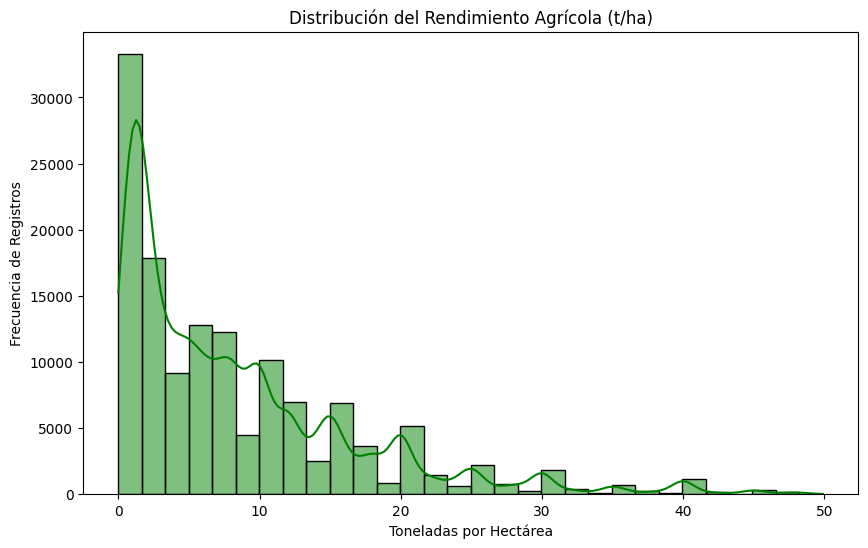

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Filtramos rendimientos menores a 50 para que la gráfica se vea bien (sin los outliers locos)
sns.histplot(df[df['Rendimiento'] < 50]['Rendimiento'], bins=30, kde=True, color='green')
plt.title('Distribución del Rendimiento Agrícola (t/ha)')
plt.xlabel('Toneladas por Hectárea')
plt.ylabel('Frecuencia de Registros')
plt.show()

**Hallazgos principales:**
* **Sesgo a la derecha:** La distribución del rendimiento agrícola presenta una asimetría positiva, donde la mayoría de los registros se concentran en valores bajos (0–10 t/ha), indicando que predominan niveles de productividad moderados o bajos.
* **Multimodalidad:** Se observan varios picos en la distribución (alrededor de 10, 20 y 30 t/ha), lo que indica que existen diferentes niveles de producción, posiblemente debido a variaciones en la forma de cultivo, el uso de tecnología o las condiciones del entorno.
* **Outliers:** La cola larga de la distribución hacia la derecha confirma la presencia de registros con rendimientos excepcionales que se alejan del promedio nacional.

## **7. Análisis de Correlaciones (Heatmap)**
Se realizó un análisis de correlación utilizando la matriz de Pearson con el fin de evaluar la relación lineal entre las variables numéricas del dataset: área sembrada, área cosechada, producción y rendimiento.



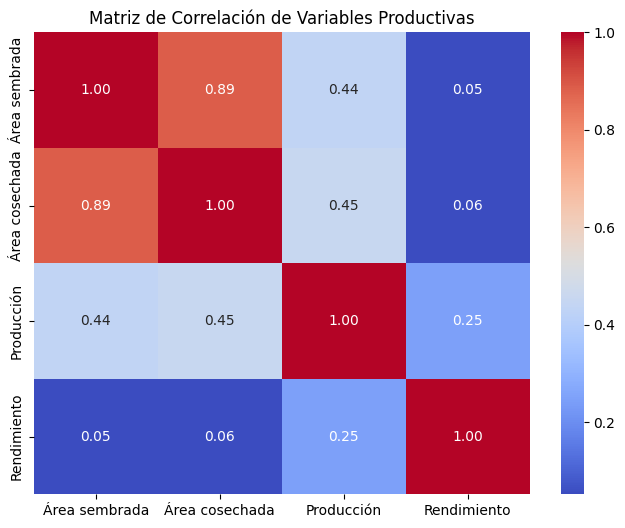

In [9]:
plt.figure(figsize=(8, 6))
correlacion = df[['Área sembrada', 'Área cosechada', 'Producción', 'Rendimiento']].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Productivas')
plt.show()

**Interpretación de coeficientes:**
* **Área Sembrada vs. Cosechada (0.89):** Hay una relación muy fuerte. Esto significa que casi toda la tierra que se siembra sí se logra cosechar. Lo que no se cosecha puede deberse a problemas como clima o plagas.
* **Producción vs. Áreas (0.44):** Correlación moderada. El volumen de producción no depende exclusivamente del tamaño del terreno, también influyen otros factores como el clima, el suelo y la forma de trabajar el cultivo.
* **Rendimiento vs Área Sembrada (0.05):** Casi no hay relación. Esto significa que el rendimiento no depende del tamaño del terreno, sino de qué tan bien se produce. Un productor pequeño puede rendir igual que uno grande si trabaja bien.